<div style="border:solid Chocolate 2px; padding: 40px">
 
<b> Александр, привет!👋</b> 

Меня зовут Кирилл Васильев, я буду ревьюером твоего проекта. Я предлагаю общаться на «ты», но если привычнее на «вы», просто скажи об этом! 

Я буду оставлять комментарии в твоем проекте. Пожалуйста, не удаляй их, они могут быть полезны в случае повторной проверки.

Свои комментарии я буду обозначать <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:
  
<br/> 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным. Здесь же я могу давать советы и предложения.
</div>
 
<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div> 
  

<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

  
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>  


<br/>
<div class="alerфt alert-info">
Рекомендую для твоих комментариев использовать синий или любой другой цветной фон. Я постараюсь ничего не пропустить, но если комментарии будут выделены, то это мне очень поможет!
</div>
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой руководитель будет поступать также. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.



# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Клиент - компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды. До этого аналитики компании использовали простую линейную регрессию, качество предсказаний которой не удовлетворяет требованиям компании.  

Задача: предложить компании BikeSochi новую, более гибкую модель для прогнозирования спроса на велосипеды.  

Модели — k-NN и дерево решений, при подборе гиперпараметров необходимо применить единую схему кросс-валидации с 5 фолдами.

Метрики: RMSE, R² и MAE

Целевая метрика для выбора модели - RMSE.


<div class="alert alert-success">
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

👍 Отлично по описанию. Цели и задачи ясны, обозначены корректно. Контекст будет понятен любому читателю.
 

In [1]:
# Удаляем старые версии
!pip uninstall -y numpy pandas scipy scikit-learn matplotlib seaborn pyarrow phik -q

# Ставим совместимые версии
!pip install  \
numpy==1.26.4 \
pandas==2.2.3 \
scipy==1.13.1 \
scikit-learn==1.6.1 \
matplotlib==3.9.0 \
seaborn==0.13.2 \
pyarrow==18.1.0 \
phik==0.12.4 \
joblib==1.4.2 \
numba==0.59.0 \
optuna==4.0.0 \
cloudpickle==3.0.0 -q

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import optuna
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, average_precision_score, log_loss, make_scorer, brier_score_loss, PrecisionRecallDisplay, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator, calibration_curve
from sklearn.feature_selection import RFE, VarianceThreshold, SequentialFeatureSelector as SFS, SelectFromModel
from sklearn.multiclass import OneVsRestClassifier
from sklearn.compose import TransformedTargetRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import joblib
import json
import optuna.visualization as vis
import cloudpickle
!pip install phik -q
from phik import phik_matrix

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Замечательно по инсталлам и оформлению импортов

 

In [3]:
try: df_train = pd.read_csv(r'C:\Users\User\Google Диск\DS\ds_s14_train_data.csv')
except: df_train = pd.read_csv('/datasets/ds_s14_train_data.csv')

In [4]:
try: df_test = pd.read_csv(r'C:\Users\User\Google Диск\DS\ds_s14_test_data.csv')
except: df_test = pd.read_csv('/datasets/ds_s14_test_data.csv')

# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

In [5]:
base_model = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')

In [6]:
X_test = df_test.drop(columns=('Rented Bike Count'))

In [7]:
y_test = df_test['Rented Bike Count']

In [8]:
y_pred_base = base_model.predict(X_test) 

In [9]:
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = root_mean_squared_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)
print(f"RMSE базовой модели: {round(rmse_base,3)}")
print(f"MAE базовой модели: {round(mae_base,3)}")
print(f"R2 базовой модели: {round(r2_base,3)}")

RMSE базовой модели: 411.564
MAE базовой модели: 312.599
R2 базовой модели: 0.586


Значение R2 = 0.586 означает, что базовая модель объясняет 58.6% дисперсии целевой переменной, то есть модель уловила чуть больше половины закономерностей в данных. Это довольно низкий показатель.    
Базовая модель - линейная регрессия, она не может учесть возможно имеющуюся нелинейную связь между признаками и целевой переменной.   
Есть возможность улучшения качества предсказаний посредством применения моделей, которые могут учесть нелинейные зависимости: k-NN и решающее дерево.  

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Верно по коду.

<div class="alert alert-block alert-danger" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>
    
Добавим краткое пояснение по качеству модели, возможно, по необходимости и возвожмонти улучшения.

<div class="alert alert-info">
Комментарий студента V1
    
Привет, Кирилл! Краткое пояснение добавил
</div>

# **Часть 2: Улучшение модели — KNN и Decision Tree**

## EDA

### Общий анализ датасета

In [10]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [11]:
display(df_train)

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003,-4.2,40.0,0.9,1216.0,-15.8,0.00,0.0,0.0,Winter,No Holiday,Yes,True,False,False,False,410
7004,2.9,51.0,0.8,1119.0,-6.2,0.00,0.0,0.0,Spring,No Holiday,Yes,False,False,False,True,163
7005,5.3,73.0,0.7,2000.0,0.8,0.01,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1142
7006,4.4,64.0,1.4,2000.0,-1.8,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,362


In [12]:
print(f'Полных дубликатов: {df_train.duplicated().sum()}')

Полных дубликатов: 0


Проверим количество уникальных значений в категориальных и булевых признаках.

In [13]:
print(df_train[['Seasons', 'Holiday', 'Functioning Day', 'Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning',
            'Time_Period_Night']].nunique().sort_values(ascending=False))

Seasons                     4
Holiday                     2
Functioning Day             2
Time_Period_Evening         2
Time_Period_Late Evening    2
Time_Period_Morning         2
Time_Period_Night           2
dtype: int64


1. Обучающий датасет имеет 16 колонок (15 признаков и 1 целевая переменная) и 7008 строк.
2. Наименования признаков написаны не в стиле snake_case, однако переименовывать признаки не имеет смысла, поскольку в продакшене в модель будут подаваться именно таким образом поименованные признаки.
3. В данных есть пропуски. 
4. Полных дубликатов строк нет.
5. Поскольку мы будем использовать методы KNN и Decision Tree, а они у них разные требования к подготовке данных, то для универсальности подготовки нужно привести признаки с булевым типом и категориальные признаки с двумя значениями категорий к бинарному типу, а также восстановить 5-й признак времени суток - день. 


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Отлично по первому анализу данных и выводам



### Распределение числовых признаков

In [14]:
df_train.describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


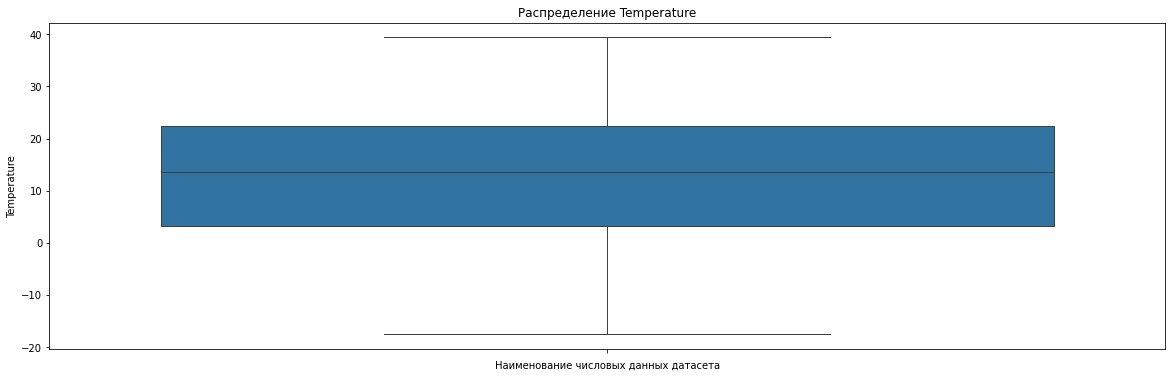

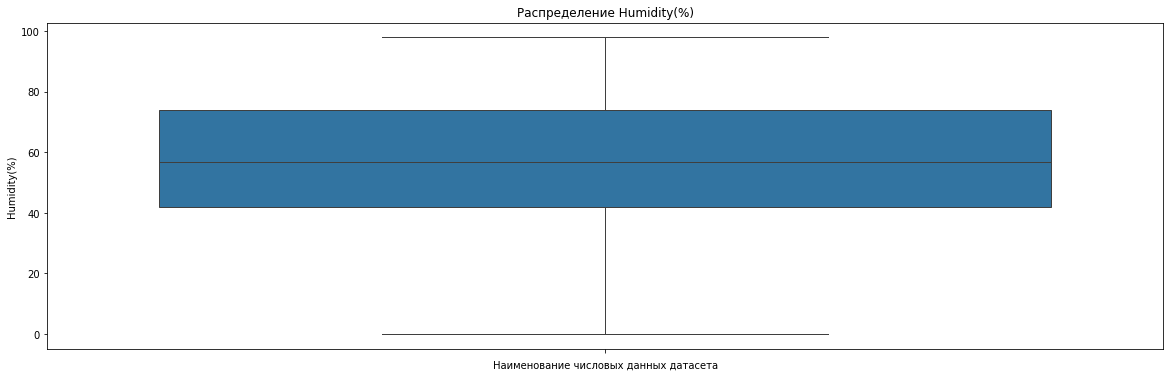

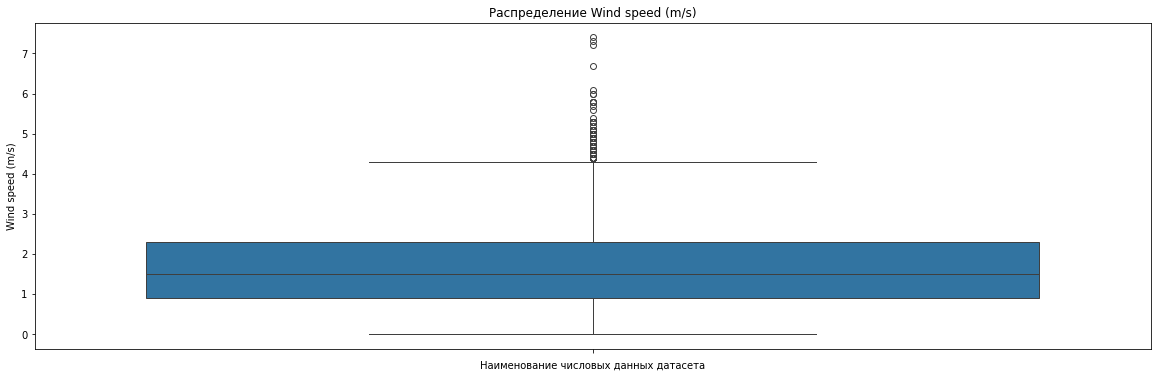

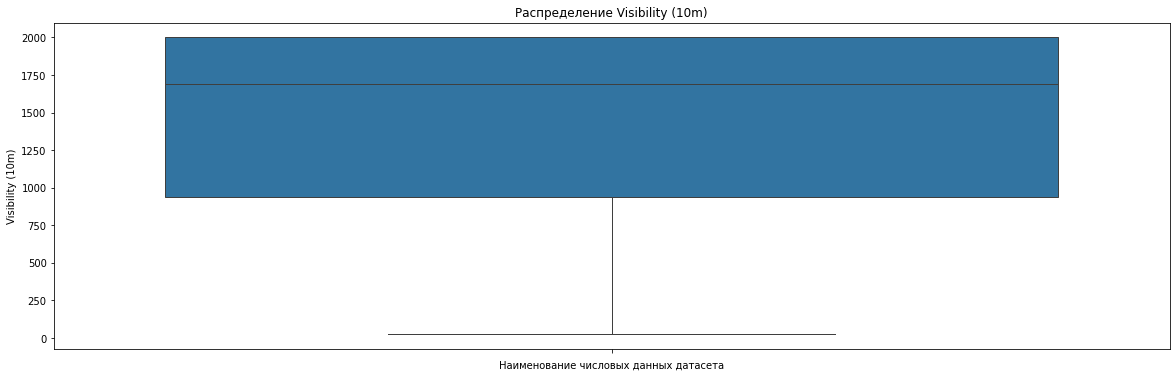

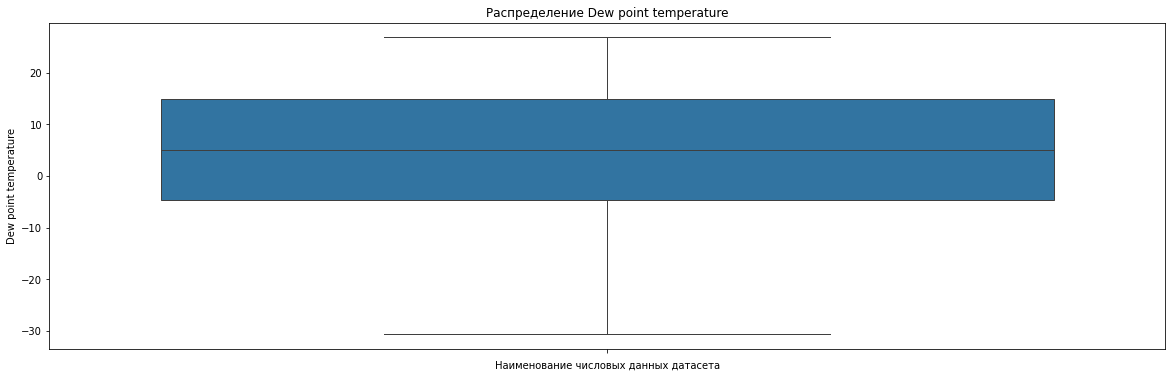

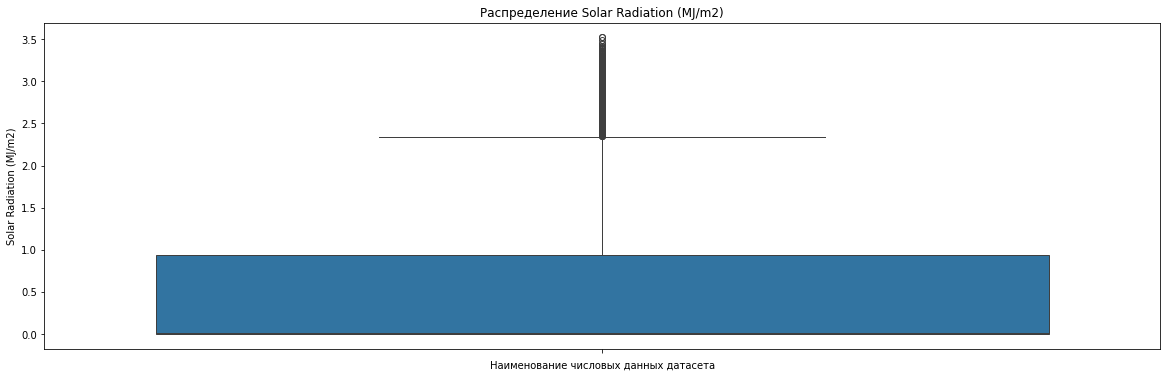

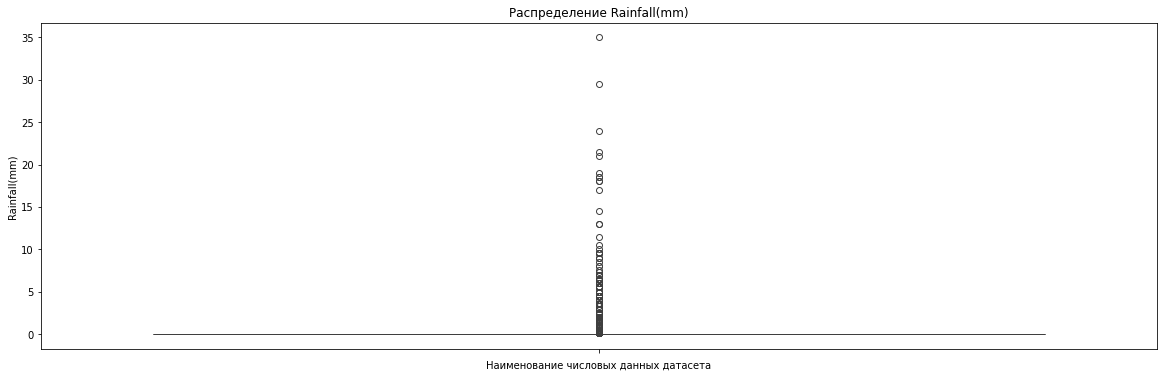

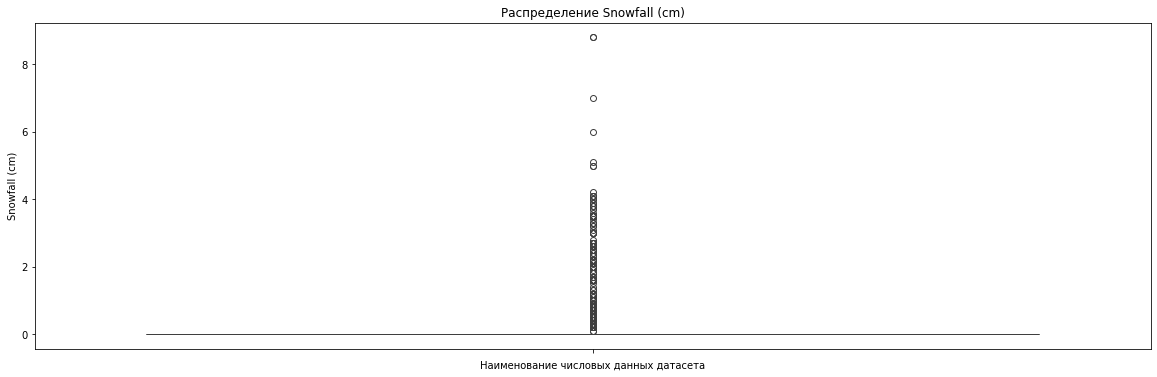

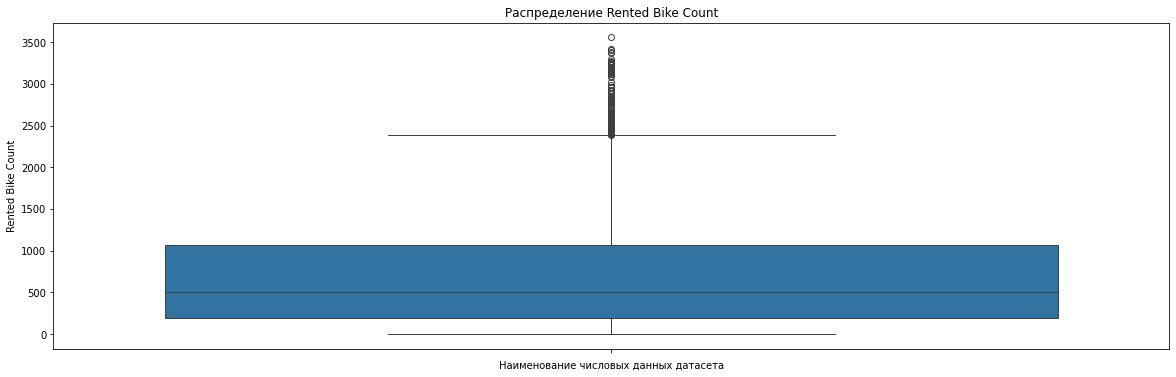

In [15]:
for col in ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)',
            'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count']:
    plt.figure(figsize=(20, 6))
    sns.boxplot(data=df_train[col])
    plt.title(f'Распределение {col}')
    plt.xlabel('Наименование числовых данных датасета')
    plt.show()

- Temperature, Humidity(%) имеют нормальное распределение  
- Wind speed (m/s) имеет выбросы справа  
- Visibility (10m) имеет левый хвост
- Dew point temperature имеет распределение, близкое к нормальному
- Solar Radiation (MJ/m2) имеет правый хвост с выбросами
- Rainfall(mm) и Snowfall(сm) содержат разреженные данные: большинство значений равно 0 
- целевая переменная Rented Bike Count имеет правый хвост с выбросами

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Ага, у нас количество событий в единицу времени, это классический случай пуассоновсного распределения. При малом количестве событий оно имеет ровно такую форму, как у нас на графике выше, хвост справа абсолютно ожидаем, а значения − реалистичны. Так как в задаче спроса важно предсказывать и пиковые нагрузки, к высоким значениям у нас будет особый интерес. Если значения реалистичны, то даже и за пределами 99-перцентиля лучше их оставить как есть. 



#### Подробнее изучим выбросы целевой переменной 

In [16]:
q1 = df_train['Rented Bike Count'].quantile(0.25)
q3 = df_train['Rented Bike Count'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outliers_count = (df_train['Rented Bike Count'] > upper_bound).sum()
print(f"Значение верхнего уса для Rented Bike Count: {upper_bound}")
print(f"Количество значений Rented Bike Count за верхним усом: {outliers_count}")


Значение верхнего уса для Rented Bike Count: 2388.875
Количество значений Rented Bike Count за верхним усом: 121


In [17]:
display(df_train[df_train['Rented Bike Count']>2389])

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
36,25.9,52.0,2.1,2000.0,15.2,0.57,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,3196
206,28.2,64.0,2.8,1978.0,20.7,0.50,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2637
516,28.0,46.0,2.3,1833.0,15.2,1.23,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2451
557,21.2,52.0,3.6,1856.0,10.9,0.55,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6594,16.0,47.0,2.1,2000.0,4.6,0.79,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2402
6602,23.3,68.0,3.6,895.0,17.0,0.11,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,2519
6729,28.4,75.0,NaN,1564.0,23.5,0.52,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2931
6838,21.2,NaN,3.8,1927.0,3.8,0.94,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,2807


In [18]:
df_train[df_train['Rented Bike Count']>2389].describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,121.000000,119.000000,112.000000,114.000000,121.000000,117.000000,117.000000,120.0,121.000000
mean,24.285124,50.495798,2.148214,1709.736842,12.770248,0.596496,0.000855,0.0,2720.223140
std,4.634664,11.999911,0.823854,420.496126,5.939636,0.473309,0.009245,0.0,307.159771
min,12.200000,18.000000,0.500000,554.000000,-7.100000,0.000000,0.000000,0.0,2392.000000
25%,22.200000,42.500000,1.475000,1500.500000,8.300000,0.160000,0.000000,0.0,2468.000000
50%,24.800000,51.000000,2.250000,1976.500000,13.600000,0.520000,0.000000,0.0,2615.000000
75%,27.100000,59.000000,2.800000,2000.000000,16.600000,0.960000,0.000000,0.0,2916.000000
max,35.400000,77.000000,4.100000,2000.000000,23.500000,2.540000,0.100000,0.0,3556.000000


Выводы
1. количество выбросов в целевой переменной - 121 строка из 7008 — это всего 1.7% от обучающего датасета - небольшая доля аномалий, однако это количество охватывает диапазон от 2389 до 3556 арендованных велосипедов, при медиане всего обучающего датасета в 505 штук. 
2. Краткое изучение выбросов показывает, что это не технический брак, а реальные пиковые данные, удалять их нельзя, потому что модель должна уметь предсказывать такие пики.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Да, реальные данные, оставляем.
    


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Я бы посмотрел гистограммы, они нагляднее. Можно прикинуть, нужно ли логарифмирование для деревьев или проблема не такая большая.

<br/> <div class="alert alert-info">
Комментарий студента V1
    
Я тут немного не понял: гистограмму вместо боксплота? Я посмотрел распределение значений целевой переменной с помощью боксплота и потом перешел к исследованию выбросов. Логарифмирование целевой переменной потом убрал.
</div>

#### Более подробно посмотрим на признаки Rainfall(mm) и Snowfall (cm)

In [19]:
print(f"Количество ненулевых данных о размере осадков: {(df_train['Rainfall(mm)'] > 0).sum()}")
print(f"Количество ненулевых данных о количестве снега :{(df_train['Snowfall (cm)'] > 0).sum()}")

Количество ненулевых данных о размере осадков: 385
Количество ненулевых данных о количестве снега :342


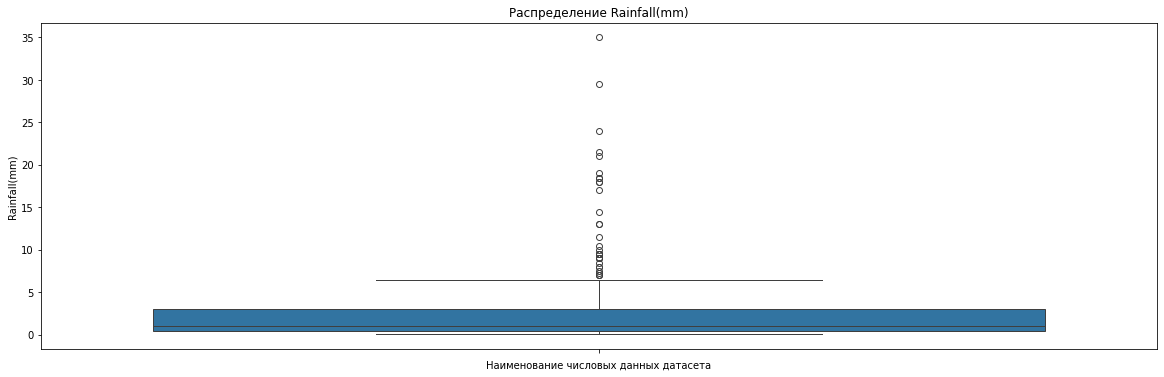

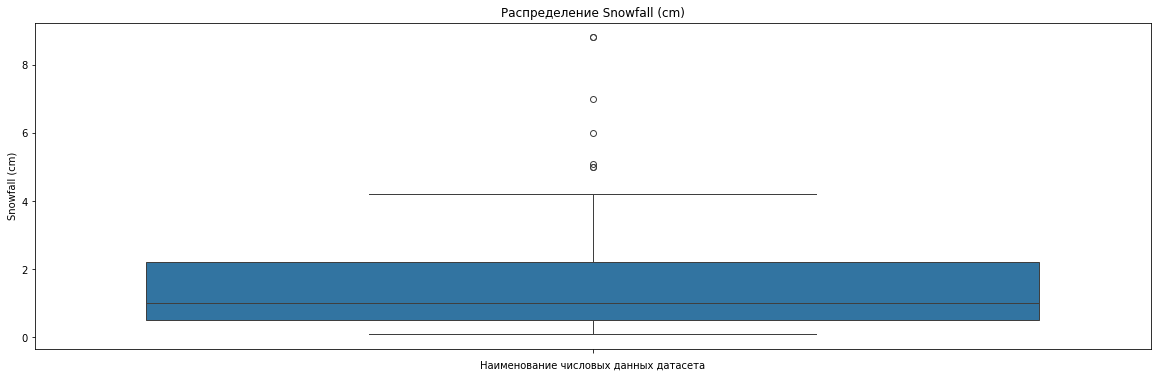

In [20]:
for col in ['Rainfall(mm)', 'Snowfall (cm)']:
    plt.figure(figsize=(20, 6))
    sns.boxplot(data=df_train[df_train[col]>0][col])
    plt.title(f'Распределение {col}')
    plt.xlabel('Наименование числовых данных датасета')
    plt.show()

Выводы:
1. Данные о дожде или снеге содержатся в 10,4 % строк датасета. Это нормальная картина - большую часть года осадков нет. Большое количество нулевых значений — это не пропуски и не ошибки.
2. Скорее всего, наличие данных об осадках имеет влияние на значение целевой переменной: в дождь, а тем более снег ездить на велосипеде не очень комфортно.
3. Распределение ненулевых значений признаков показывает наличие длинного правого хвоста, особенно у признака Rainfall(mm), значит, к значениям нужно будет применить логарифмирование.

### Распределение целевой переменной по значениям категориальных признаков

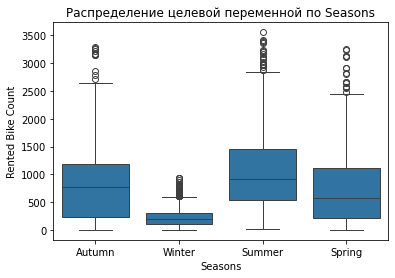

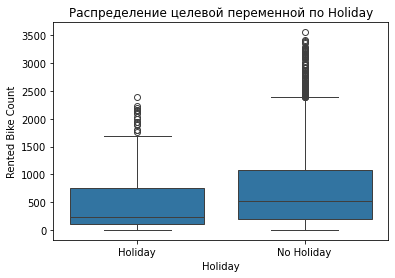

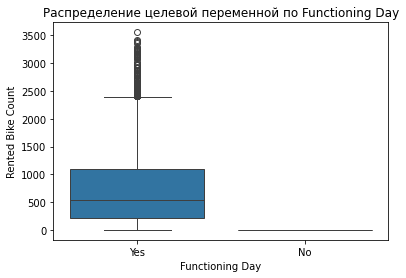

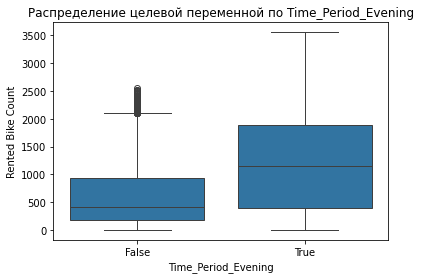

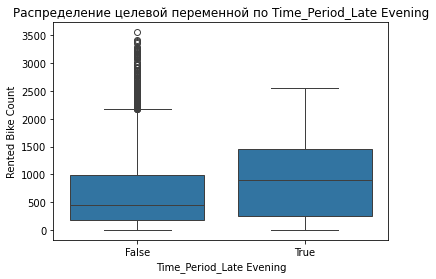

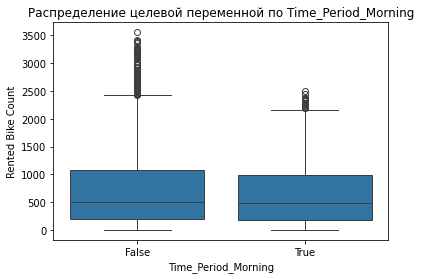

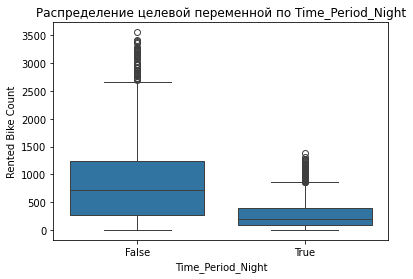

In [21]:
for col in ['Seasons', 'Holiday', 'Functioning Day', 'Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning',
            'Time_Period_Night']:
    sns.boxplot(data=df_train, x=col, y='Rented Bike Count')
    plt.title(f'Распределение целевой переменной по {col}')
    plt.show()

1. Seasons  
Явно видно, что количество арендуемых велосипедов различается по сезонам, что естественно: зимой значения ниже, чем в остальных трех сезонах, летом выше, а осенью и весной примерно одинаковые, хотя медиана осени выше, чем медиана весны.Логичное распределение целевой переменной по сезонам. Этот признак должен иметь высокую важность для модели.
2. Holiday  
Интересно, что объемы аренды велосипедов больше в будние дни, чем в выходные и праздничные. И боксплот рабочих дней шире и медиана выше. Можно предположить, что спрос на велосипеды, в основном, создают туристы, и на этот спрос не влияет выходной день или будний, но это все равно не объясняет, почему спрос в выходные меньше, чем в будние. Этот признак тоже должен иметь важность для модели.  
3. Functioning Day  
Похоже, при значении "No" целевая переменная принимает нулевое значение. Надо более подробно изучить распределение целевой переменной по значениям признака 'Functioning Day'.
4. Группа признаков Time_Period  
Явно видно, что распределение целевой переменной по времени дня различно: ночью самые маленький размах значений, утром побольше, а самые большой разброс приходится на вечер и поздний вечер. Особенно на вечер: имеено на этот период дня выпадают самый большой размах значений целевой переменной - от 0 до 3500, т.е. от минимума до максимума. И если на общем боксплоте целевой переменной мы видим значения от 2392 до 3556 как выбросы, то на боксплоте вечернего периода эти значения покрываются верхним усом боксплота. Такое распределение реалистично, эти признаки должны иметь высокое значение для модели. 



<div class="alert alert-block alert-danger" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>
    
`По графикам видно, что целевая переменная имеет разное распределение по значениям категориальных признаков, значит эти признаки будут иметь важное значение для моделирования.` - такой комментарий можем оставить примерно к чему угодно. Он бесполезен и неинформативен.
    
    
Давай добавим конкретики, по каким признакам различия больше, какие признаки будут выглядеть важными, как это соотносится с нашими представлениями о предметной области, насколько данные и закономерности реалистичны, есть ли что-то контринтуитивное. КАкие выводы делаем, как можем использовать информацию при моделировании?

<br/> <div class="alert alert-info">
Комментарий студента v1
    
Конкретики добавил.
</div>

In [22]:
print(f"Количество отрицательных значений признака 'Functioning Day': {(df_train['Functioning Day'] == 'No').sum()}")

Количество отрицательных значений признака 'Functioning Day': 242


In [23]:
df_train[df_train['Functioning Day'] == 'No'].describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,242.000000,235.000000,235.000000,229.000000,242.000000,239.000000,234.000000,233.0,242.0
mean,16.126446,59.765957,1.740000,1520.318777,7.643388,0.653138,0.105128,0.0,0.0
std,4.764230,16.390810,1.126268,570.057306,4.293600,0.914491,1.190401,0.0,0.0
min,5.200000,21.000000,0.000000,201.000000,-7.000000,0.000000,0.000000,0.0,0.0
25%,12.300000,47.500000,0.900000,1060.000000,5.225000,0.000000,0.000000,0.0,0.0
50%,16.200000,61.000000,1.500000,1798.000000,7.600000,0.010000,0.000000,0.0,0.0
75%,19.400000,73.000000,2.400000,2000.000000,10.700000,1.180000,0.000000,0.0,0.0
max,26.500000,96.000000,5.300000,2000.000000,16.100000,3.320000,18.000000,0.0,0.0


In [24]:
df_train[df_train['Functioning Day'] == 'No'][['Seasons', 'Holiday', 'Functioning Day', 'Time_Period_Evening',
            'Time_Period_Late Evening', 'Time_Period_Morning','Time_Period_Night']].nunique().sort_values(ascending=False)

Seasons                     2
Holiday                     2
Time_Period_Evening         2
Time_Period_Morning         2
Time_Period_Late Evening    2
Time_Period_Night           2
Functioning Day             1
dtype: int64

In [25]:
print(f"Количество нулевых значений целевой переменной: {(df_train['Rented Bike Count'] == 0).sum()}")

Количество нулевых значений целевой переменной: 242


1. В датасете есть 242 строки, в которых значение признака 'Functioning Day' равно "No". Другие признаки в этих строках принимают разные значения, а целевая переменная равна 0.
2. В датасете есть 242 строки, в которых целевая переменная равна 0.  
То есть, значение "No" признака 'Functioning Day', независимо от значений других признаков однозначно определяет, что целевая переменная равна нулю.  
Это логично, поскольку  'No' означает, что станции проката не работают.
Следовательно, мы вообще можем исключить этот признак из обучения моделей, включив жесткое правило в процесс вызов модели: в нерабочие дни предсказание должно быть 0.

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Да, для дней, когда сервис не работает, мы можем проставлять количество заказов равным нулю. Здесь модель и предсказание не требуется.
    
Соответственно, и нам нужно будет удалить строки с нулями в дни, когда сервис не работал, а затем удалить признак как лишний.

<br/> <div class="alert alert-info">
Комментарий студента V1
    
Я так и сделал. В обучающей выборке удалил и строки с нулями и сам признак. А для теста уже обученную модель вызывал через функцию, которая дает нули в нерабочие часы. 
</div>

### Зависимость целевой переменной от значений числовых признаков

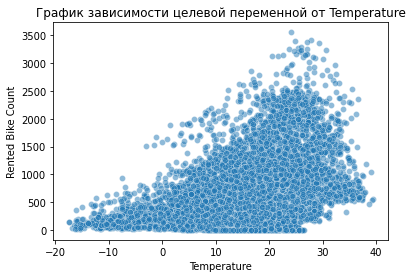

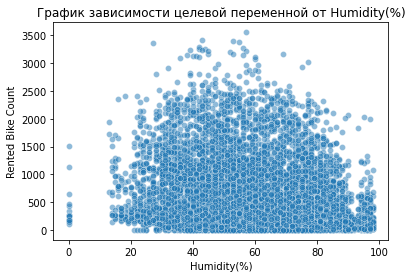

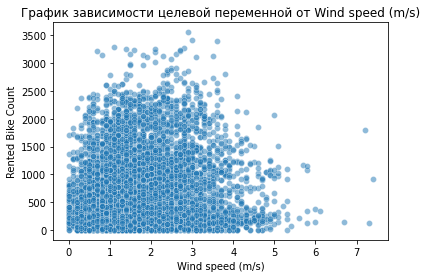

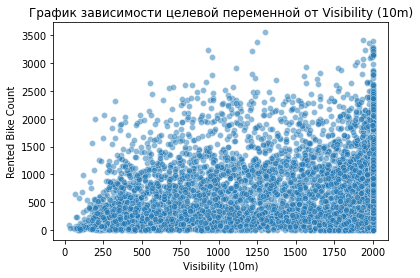

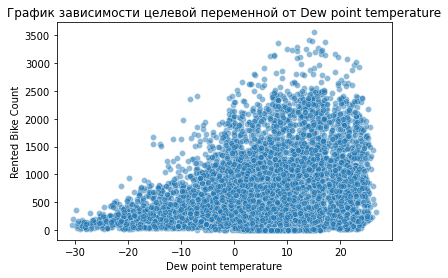

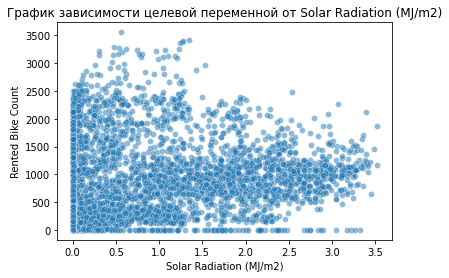

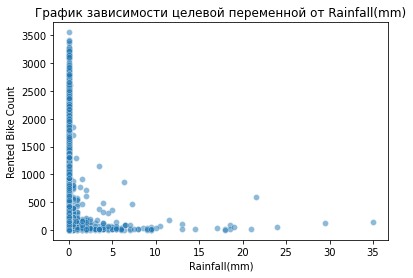

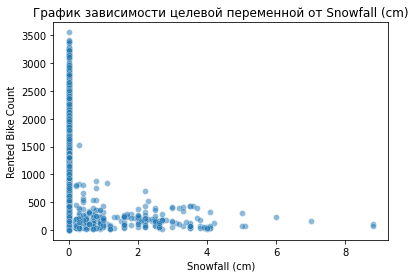

In [26]:
for col in ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)',
            'Rainfall(mm)', 'Snowfall (cm)']:
    sns.scatterplot(data=df_train, x=col, y='Rented Bike Count', alpha=0.5)
    plt.title(f'График зависимости целевой переменной от {col}')
    plt.show()

Графики зависимостей целевой переменной от числовых признаков демонстрируют отсутствие линейной зависимости между ними.

### Добавление новых признаков 

Добавим три новых признака:
1. Бинарный признак наличия осадков 'is_precipitation'. Для дерева решений этот признак может уменьшить глубину, срау указывая на факт наличия плохой погоды. Для k-NN этот признак также будет создавать максимальное расстояние между сухой погодой и осадками и модель будет искать соседей среди подмножеств "сухих" или "мокрых" дней. Исходные признаки осадков оставим для оценки их силы. 
2. Бинарный признак светлого времени суток 'is_daylight' (определяем по наличию солнечной радиации). Это позволит моделям отделять летний вечер (когда еще светло и пользоваться велосипедом приятно) от зимнего вечера (темно и на велосипеде некомфортно). Исходный же признак уровня солнечной регуляции будет служить мерой для оценки уровня освещенности.
3. Признак ощущаемой температуры 'real_feel'. Поскольку ощущаемая температура может довольно сильно отличаться от номинальной, в зависимости от силы ветра и уровня влажности, то этот признак должен оказывать сильное влияние на уровень спроса. Признак буде рассчитывать так:
- при температуре ниже 10 градусов и силе ветра больше 1,3 м/с (4,68 км/ч) считаем ветро-холодовой индекс,
- при температуре больше или равно 10 градусов считаем Хумидекс,
- при температуре ниже 10 градусов и силе ветра ниже 1,3 м/с заполняем номинальной температурой. 

In [27]:
df_train['is_precipitation'] = ((df_train['Rainfall(mm)'] > 0) | (df_train['Snowfall (cm)'] > 0)).astype(int)

In [28]:
df_train['is_daylight'] = (df_train['Solar Radiation (MJ/m2)'] > 0).astype(int)

In [29]:
# Заполняем столбец значением температуры
df_train['real_feel'] = df_train['Temperature']

T = df_train['Temperature']
V = df_train['Wind speed (m/s)'] * 3.6
D = df_train['Dew point temperature']
# --- Условие 1: Холод и сильный ветер (T < 10 и V > 1.3 м/с) ---
cold_wind_mask = (T < 10) & (V > 4.68)

# Вычисляем ветро-холодовой индекс
wind_chill = (13.12 + 0.6215 * T - 11.37 * V**0.16 + 0.3965 * T * V**0.16)

# Применяем значения по маске
df_train.loc[cold_wind_mask, 'real_feel'] = wind_chill[cold_wind_mask]

# --- Условие 2: Жара (T > 25) ---
hot_mask = T >= 10

# Вычисляем давление пара e и индекс Humidex
e = 6.11 * np.exp(5417.7530*(1/273.16-1/(273.16+D)))
humidex = T + (5 / 9) * (e - 10)

# Применяем значения по маске
df_train.loc[hot_mask, 'real_feel'] = humidex[hot_mask]

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Хорошая история. Однако правильнее будет делать расчеты на тренировочной выборке и затем применять к тестовой. Если делаем в том числе на тестовых данных - это утечка признаков.

<br/> <div class="alert alert-info">
Комментарий студента V1  
    
У нас же изначально даны два файла: с обучающими и тестовыми данными. Соотвественно я их преобразовал в два датафрейма и все эти манипуляции делаю на обучающем датафрейме.
</div>

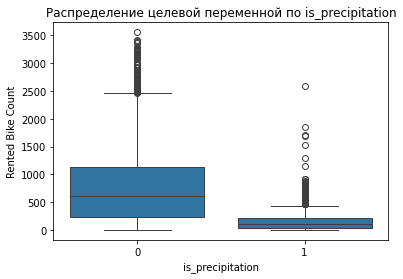

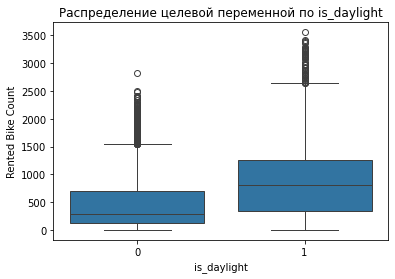

In [30]:
for col in ['is_precipitation', 'is_daylight']:
    sns.boxplot(data=df_train, x=col, y='Rented Bike Count')
    plt.title(f'Распределение целевой переменной по {col}')
    plt.show()

In [31]:
df_train[['real_feel', 'Temperature']].describe()

,real_feel,Temperature
count,7008.000000,7008.000000
mean,14.182548,12.812914
std,15.482949,11.924688
min,-25.581077,-17.500000
25%,2.200000,3.300000
50%,13.097913,13.500000
75%,26.452989,22.400000
max,49.578714,39.400000


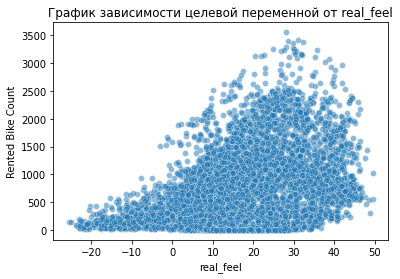

In [32]:
sns.scatterplot(data=df_train, x='real_feel', y='Rented Bike Count', alpha=0.5)
plt.title(f'График зависимости целевой переменной от real_feel')
plt.show()

Как видно целевая переменная по разному распределена по значениям признаков 'is_precipitation' и 'is_daylight', значит эти признаки могут иметь значения для моделирования.
Что каается графика зависимости целевой переменной от признака 'real_feel', то он очень похож на график зависимости целевой переменной от признака 'Temperature', что указывает на мультиколлинеарность этих признаков и необходимость выбора одного из них. 

### Корреляция между целевой переменной и признаками

In [33]:
start_time = time.time()
df_correlation = df_train.phik_matrix(interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)',
            'Rainfall(mm)', 'Snowfall (cm)', 'real_feel'])
end_time = time.time()
duration = end_time - start_time
print(f"Затраченное время: {duration / 60:.2f} минут")

/opt/conda/lib/python3.9/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable Rented Bike Count is large: 2024. Are you sure this is not an interval variable? Analysis for pairs of variables including Rented Bike Count can be slow.
  warnings.warn(


Затраченное время: 0.11 минут


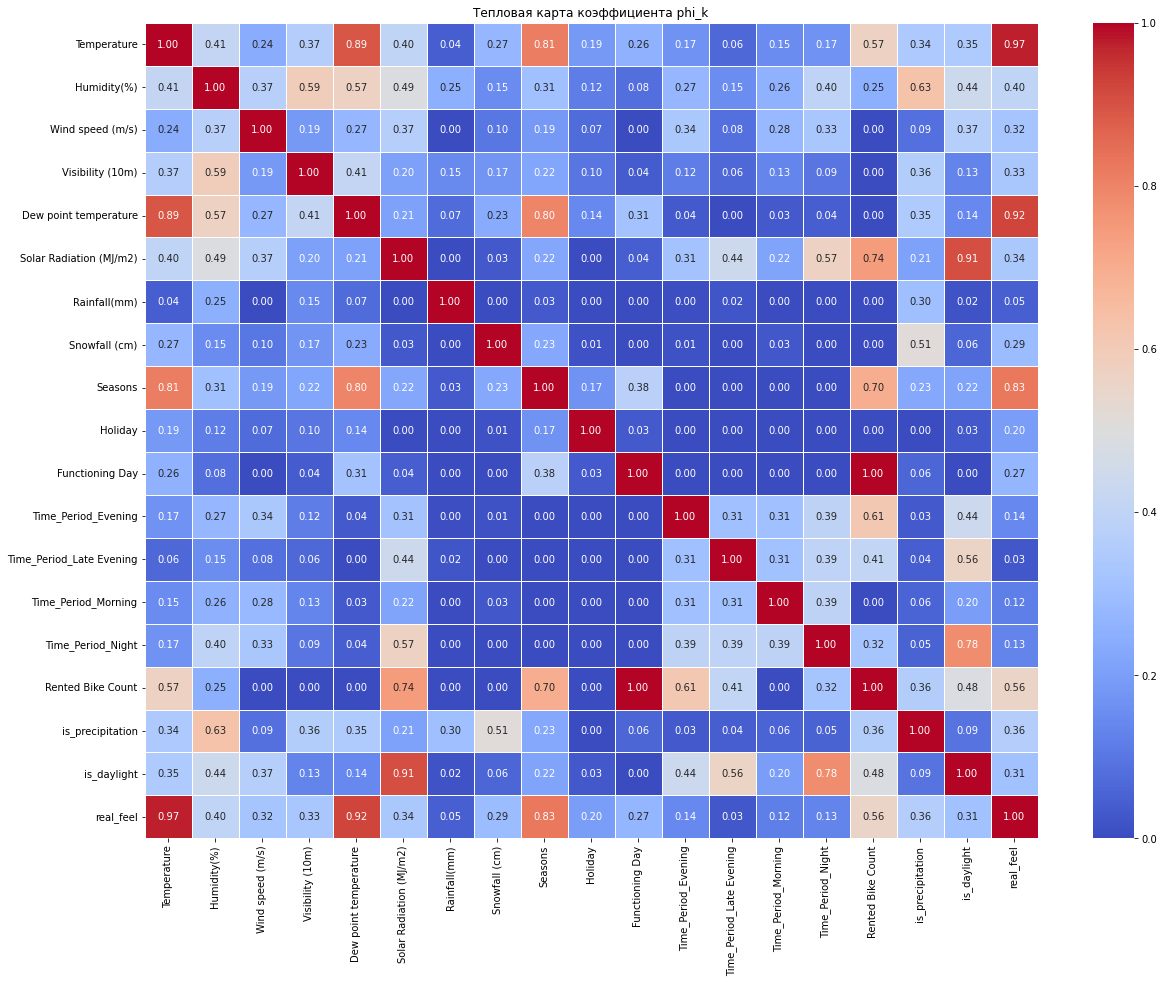

In [34]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Тепловая карта коэффициента phi_k')
plt.xlabel('')
plt.xticks(rotation=90)

plt.show()

Тепловая карта коэффициента корреляции phi-k показывает наличие полной корреляции между целевой переменной и 'Functioning Day'. Причины этого мы описали выше.

Признаки 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Time_Period_Morning' имеют коэффициент корреляции меньше, чем 0,01.

Признаки 'Wind speed (m/s)', 'Visibility (10m)' несмотря на низкий коэффициент корреляции с целевой переменной, должны влиять на поведение клиентов сервиса проката, поэтому оставим эти признаки.

Признак 'Dew point temperature' мы использовали для создания признака 'real_feel', коэффициент корреляции этих признаков 0,92, к тому у нас нет разумных причин утверждать, что поведение арендаторов велосипедов может зависеть от точки росы, поэтому мы исключим этот признак из набора.

Признаки 'Rainfall(mm)', 'Snowfall (cm)' мы изучали выше, каждый их них содержит примерно 5 % ненулевых значений. Именно такая малая доля ненулевых значений обуславливает низкое значение коэффициента корреляции. Однако, наличие дождя или снега должно сильно влиять на поведение клиентов сервиса проката, поэтому их нужно оставить.

Признак 'Holiday' тоже имеет только 95 % процентов значений буднего дня и 5 % выходных, такое распределение значений занижает коэффициент корреляции. Однако, график распределения целевой переменной по значениям этих признаков показывает, что распределение отличается, поэтому оставляем этот признак.

Признак 'Time_Period_Morning' является частью набора признаков, указывающих на время дня, поэтому оставим его.

Признаки 'real_feel' и 'Temperature' имеют коэффициент корреляции 0,97, связь этих признаков с целевой переменной практически равна: 0,56 и 0,57. Поскольку признак 'real_feel' отражает не номинальное значение температуры воздуха, а ее восприятие клиентами сервиса, то признак 'Temperature' мы исключим из набора, оставив 'real_feel'.  

Признак 'is_precipitation' имеет связь с целевой переменной 0,36, в то время как признаки-родители имеют связь ниже 0,01. В то же время, связь этого признака с признаками-родителями 'Rainfall(mm)' и 'Snowfall (cm)' равна 0,30 и 0,51 - мультиколлинеарности не возникает.  

Признак 'is_daylight' имеет очень сильную связь с признаком-родителем 'Solar Radiation (MJ/m2)' - 0,91, при этом его связь с целевой переменной - 0,48 против 0,74 у 'Solar Radiation (MJ/m2)'. Поэтому этот признак считаем излишним и откажемся от его создания.

Выводы по признакам:  

Temperature
- пропуски заполняем медианой с учетом сезона для того, чтобы создать на его основе признак 'real_feel', после чего удаляем его из датасета

Humidity(%) 
- пропуски заполняем медианой с учетом сезона
- применяем нормализацию  

Wind speed (m/s)
- пропуски заполняем медианой с учетом сезона
- применям логарифм
- применяем нормализацию

Visibility (10m)
- пропуски заполняем медианой с учетом сезона
- применяем нормализацию

Dew point temperature - удаляем

Solar Radiation (MJ/m2)
- пропуски заполняем медианой с учетом сезона
- применям логарифм
- применяем нормализацию

Rainfall(mm)
- пропуски заполняем 0
- применям логарифм
- применяем нормализацию

Snowfall (cm) пропуск
- пропуски заполняем 0
- применям логарифм
- применяем нормализацию

Seasons
- пропуски заполняем модой, если все значения пропущены - выдаем ошибку
- применяем OHE

Holiday
- пропуски заполняем значением "No Holiday" 
- переводим в бинарный формат: No Holiday - 0, Holiday - 1 (OHE не нужен, поскольку в датасете остается один столбец с 0 и 1)

Functioning Day
- поскольку в обучающем датасете мы обнаружили четкое правило: 'Functioning Day' = 'No', целевая переменная = 0, при этом остальные признаки могут принимать разные значения, то мы можем исключить этот признак из пайплайна обучения моделей, предусматривая жесткое правило в процессе вызова модели: в нерабочие часы предсказание должно быть 0, не тратя ресурсы на обучение модели на наборах признаков, в которых 'Functioning Day' = 'No'
- мы также должны исключить из обучающего датасета строки, в которых 'Functioning Day' = 'No' для того, чтобы модели не искали сочетания признаков, при которых целевая переменная = 0 и не переобучались
- в продакшене, в обученную модель будут подаваться строки с любыми значениями 'Functioning Day', в тех строках где 'Functioning Day' = 'No' модели будут выдавать какое-то предсказание, которое будет заменяться на 0
- в обучающем датасете пропусков в этом признаке нет, если в продакшене встретится пропуск в этих данных, тогда по умолчанию этот пропуск будет считаться равным 'Yes' и по ним будет выдаваться предсказание, отличное от нуля, так как только предсказания по строкам со значением 'No' будут обнуляться   

Time_Period_Evening
- пропуски заполняем значением False
- перевод в бинарный формат  

Time_Period_Late Evening
- пропуски заполняем значением False
- перевод в бинарный формат  

Time_Period_Morning
- пропуски заполняем значением False
- перевод в бинарный формат  

Time_Period_Night
- пропуски заполняем значением False
- перевод в бинарный формат  

добавляем признак Time_Period_day
- заполняем 1 в тех строках, где предыдущие 4 признака части дня имеют 0 значения и 0, там где хотя бы один из них не равен 0

добавляем признак is_precipitation  
- пропусков в нем быть не должно, так как мы заполнили пропуски в признаках-родителях
- признак уже в бинарном формате, нормализовывать его не нужно  

добавляем признак real_feel  
- пропусков в нем быть не должно, так как мы заполнили пропуски в признаках-родителях
- применяем нормализацию

Целевую переменную также логарифмируем.  

Модель k-NN имеет гораздо более требовательна к подготовке данных, чем дерево решений: для дерева решений не нужна нормализация и логарифмирование. Задача у нас состоит в выборе лучшей модели. Поэтому, для того, сделать универсальное решение, избегая ненужных действий, сделаем разные пайплайны подготовки данных для моделей.   
Общий этап подготовки - заполнение пропусков и создание новых признаков. Далее для k-NN проводим нормализацию, логарифмирование и кодирование с помощью OHE. Для дерева решений - кодирование с помощью OHE.

<div class="alert alert-block alert-danger" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>
    
`Целевую переменную также логарифмируем.` - кажется, много лишних действий ради (в нашем случае) околонулевого результата. Нужно будет делать обратное логарифмирование перед расчетом метрик. Особенно неудобно это будет для кросс-валидации. Деревья относительно нечувствительны к выбросам, выбросы у нас небольшие. Так что логарифмирование видется излишним.
    
***
    
Functioning Day - здесь тоже как-то ты все усложняешь. Если кран закрыт, вода не льется, конец предложения. Если в какие-то дни сервис не работал - нужно удалить эти дни и затем удалить признак-маркер таких дней. Нам не нужно показывать модели такие наблюдения. При внедрении действительно мы легко сможем реализовать логику заполнения нулями показателей аренды для дней, когда сервис не работает.

<br/> <div class="alert alert-info">
Комментарий студента V1  
В принципе, применение объеста TransformedTargetRegressor упрощает логарифимирование и обратное преобразование значения целевой переменной и не доставляет неудобств при кросс-валидации.  
Но по итогам я убрал логарифмирование целевой переменной, при этом у обеих моделей MSE немного уменьшилось (DT с 324,39 до 322,47 k-NN c 313,91 до 309,92) MAE немного выросло (DT c 213 до 216,46 k-NN с 204,53 до 211,46) R2 выросло на доли процента, практически не изменилось. Количество соседей у лучшей k-NN увеличилось с 9 до 12. 
    
По Functioning Day я изначально не усложнял: убрал и признак и строки с нулями из обучающей выборки, для тестовой выборки и продакшена сделал функцию, которая сразу ставит нули в нерабочий день.
</div>

<div class="alert alert-block alert-danger" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>
  
<b>На доработку🤔:</b>
    
Есть ли у нас высокоскоррелированные признаки? Стоит ли убрать что-то из пары таких признаков? Присмотрись, кажется, у нас два одинаковых признака температуры, хватит одного.

<br/> <div class="alert alert-info">
Комментарий студента V1
    
Да, я так и написал выше: "Признаки 'real_feel' и 'Temperature' имеют коэффициент корреляции 0,97, связь этих признаков с целевой переменной практически равна: 0,56 и 0,57. Поскольку признак 'real_feel' отражает не номинальное значение температуры воздуха, а ее восприятие клиентами сервиса, то признак 'Temperature' мы исключим из набора, оставив 'real_feel'."  
Признак 'Temperature' удаляется из датасета в общем трансформере BikeDataPreprocessor после того, как на его основе создан признак 'real_feel'. 
</div>

## Создание и обучение моделей

### Создадим обучающий датасет и выделим целевую переменную

In [35]:
df_train_red = (df_train[df_train['Functioning Day'] == 'Yes']) 
y_train = df_train_red['Rented Bike Count']
X_train=df_train_red.drop(columns=['is_precipitation', 'is_daylight', 'real_feel', 'Rented Bike Count'])

In [36]:
X_train.shape, y_train.shape

((6766, 15), (6766,))

### Общий трансформер: заполнение пропусков и создание новых признаков

In [37]:
class BikeDataPreprocessor(BaseEstimator, TransformerMixin):
    """
    Класс для общего этапа: заполнение пропусков,
    создание новых признаков и базовая бинаризация.
    """
    def __init__(self):
        self.seasonal_medians_ = {}
        self.seasons_mode_ = None
        self.feature_names_in_ = None   # Сохраним имена колонок на входе
        self.feature_names_out_ = None  # Сохраним имена колонок на выходе
        super().__init__()

    def fit(self, X, y=None):
        # Корректно приводим к DataFrame с сохранением имен колонок
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
            self.feature_names_in_ = X.columns.tolist()
        else:
            X_df = pd.DataFrame(X).copy()
            self.feature_names_in_ = X_df.columns.tolist()
        
        # Определяем моду для Seasons
        if 'Seasons' in X_df.columns:
            if X_df['Seasons'].isna().all():
                raise ValueError("Критическая ошибка: Все значения в столбце 'Seasons' пропущены!")
            self.seasons_mode_ = X_df['Seasons'].mode()[0]
            X_df['Seasons'] = X_df['Seasons'].fillna(self.seasons_mode_)
        
        # Считаем медианы с учетом сезона для непрерывных признаков
        target_cols = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)']
        for col in target_cols:
            if col in X_df.columns:
                medians = X_df.groupby('Seasons')[col].median()
                overall_median = X_df[col].median()
                self.seasonal_medians_[col] = medians.to_dict()
                self.seasonal_medians_[f"{col}_overall"] = overall_median
                
        # --- Считаем имена выходных колонок заранее ---
        # Имитируем трансформацию без вычислений, чтобы узнать финальный список колонок
        cols = list(self.feature_names_in_)
        time_cols = ['Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']
        
        if all(c in cols for c in time_cols):
            cols.append('Time_Period_day')
        if 'Rainfall(mm)' in cols and 'Snowfall (cm)' in cols:
            cols.append('is_precipitation')
        if 'Temperature' in cols:
            cols.append('real_feel')
            
        cols_to_drop = ['Temperature', 'Dew point temperature', 'Functioning Day']
        self.feature_names_out_ = [c for c in cols if c not in cols_to_drop]
                
        return self

    def transform(self, X):
        # Восстанавливаем имена колонок, если на вход пришел массив NumPy
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        
        # --- Заполнение пропусков ---
        if 'Seasons' in X_df.columns:
            X_df['Seasons'] = X_df['Seasons'].fillna(self.seasons_mode_)
            
        target_cols = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)']
        for col in target_cols:
            if col in X_df.columns:
                X_df[col] = X_df.apply(
                    lambda row: self.seasonal_medians_[col].get(row['Seasons'], self.seasonal_medians_[f"{col}_overall"]) 
                    if pd.isna(row[col]) else row[col], axis=1
                )
                
        for col in ['Rainfall(mm)', 'Snowfall (cm)']:
            if col in X_df.columns:
                X_df[col] = X_df[col].fillna(0.0)
                
        if 'Holiday' in X_df.columns:
            X_df['Holiday'] = X_df['Holiday'].fillna("No Holiday")
            
        time_cols = ['Time_Period_Evening', 'Time_Period_Late Evening', 'Time_Period_Morning', 'Time_Period_Night']
        for col in time_cols:
            if col in X_df.columns:
                X_df[col] = X_df[col].fillna(False)

        # --- Создание и трансформация признаков ---
        if 'Holiday' in X_df.columns:
            X_df['Holiday'] = X_df['Holiday'].map({'No Holiday': 0, 'Holiday': 1}).astype(int)
            
        for col in time_cols:
            if col in X_df.columns:
                X_df[col] = X_df[col].astype(int)
                
        if all(c in X_df.columns for c in time_cols):
            X_df['Time_Period_day'] = (X_df[time_cols].sum(axis=1) == 0).astype(int)
            
        if 'Rainfall(mm)' in X_df.columns and 'Snowfall (cm)' in X_df.columns:
            X_df['is_precipitation'] = ((X_df['Rainfall(mm)'] > 0) | (X_df['Snowfall (cm)'] > 0)).astype(int)
            
        # Расчет real_feel
        if 'Temperature' in X_df.columns:
            X_df['real_feel'] = X_df['Temperature']
            V = X_df['Wind speed (m/s)'] * 3.6
            T = X_df['Temperature']
            
            if 'Dew point temperature' in X_df.columns:
                D = X_df['Dew point temperature']
                e = 6.11 * np.exp(5417.7530 * (1 / 273.16 - 1 / (273.16 + D)))
                humidex = T + (5 / 9) * (e - 10)
                hot_mask = T >= 10
                X_df.loc[hot_mask, 'real_feel'] = humidex[hot_mask]
            
            wind_chill = 13.12 + 0.6215 * T - 11.37 * (V ** 0.16) + 0.3965 * T * (V ** 0.16)
            cold_wind_mask = (T < 10) & (V > 4.68)
            X_df.loc[cold_wind_mask, 'real_feel'] = wind_chill[cold_wind_mask]
        
        # --- Удаление ненужных признаков ---
        cols_to_drop = ['Temperature', 'Dew point temperature', 'Functioning Day']
        X_df = X_df.drop(columns=[col for col in cols_to_drop if col in X_df.columns])
        
        # Гарантируем правильный порядок колонок для set_output
        return X_df[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        """Обязательный метод для поддержки set_output(transform='pandas')"""
        return np.array(self.feature_names_out_, dtype=object)


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Возможно, для читаемости кода и простоты решения стоило бы воспользоваться стандартным sklearn-овским препроцессингом? 
    
Генерацию фичей можем реализовать отдельно от пайплайна.

<br/> <div class="alert alert-info">
Комментарий студента V1
1. У нас было дополнительное задание создать кастомный трансформер признаков, что я и сделал.
2. При создании модели я исхожу из того, что надо предусмостреть все возможные варианты использования ее в продакшене. Прогнозируем мы почасовой спрос, и, значит можно предположить, что модель будет использоваться для прогнозирования спроса на нескольких дней. Но это только предположение, уточнить у клиента я не имею возможности, поэтому устраняю все возможные варианты ошибок из-за пропусков в признаках. Поэтому в трасформере признаков я не только создаю новые признаки, но и заполняю пропуски с учетом того, что, например, в модель может быть загружена информация с полностью пропущенными данными по одному из признаков и невозможно будет заполнить ее медианными значениями из этого набора, поэтому запоминаю сезонные медианы признаков из обучающего набора. С помощью SimpleImputer это сделать невозможно.   

In [38]:
preprocessor = BikeDataPreprocessor()
df = preprocessor.fit_transform(X_train)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6766 entries, 0 to 7007
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Humidity(%)               6766 non-null   float64
 1   Wind speed (m/s)          6766 non-null   float64
 2   Visibility (10m)          6766 non-null   float64
 3   Solar Radiation (MJ/m2)   6766 non-null   float64
 4   Rainfall(mm)              6766 non-null   float64
 5   Snowfall (cm)             6766 non-null   float64
 6   Seasons                   6766 non-null   object 
 7   Holiday                   6766 non-null   int64  
 8   Time_Period_Evening       6766 non-null   int64  
 9   Time_Period_Late Evening  6766 non-null   int64  
 10  Time_Period_Morning       6766 non-null   int64  
 11  Time_Period_Night         6766 non-null   int64  
 12  Time_Period_day           6766 non-null   int64  
 13  is_precipitation          6766 non-null   int64  
 14  real_feel    

In [40]:
df.describe()

,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Time_Period_day,is_precipitation,real_feel
count,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000,6766.000000
mean,58.114248,1.719613,1441.872155,0.551346,0.142832,0.074520,0.047443,0.166864,0.168046,0.166864,0.249778,0.248448,0.103311,14.070127
std,20.133966,1.025001,600.491281,0.855496,1.141530,0.437528,0.212600,0.372882,0.373935,0.372882,0.432917,0.432145,0.304387,15.737850
min,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-25.581077
25%,43.000000,0.900000,960.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.900000
50%,58.000000,1.500000,1713.500000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.628662
75%,73.000000,2.300000,1996.750000,0.890000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.912430
max,98.000000,7.400000,2000.000000,3.520000,35.000000,8.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,49.578714


Трансформер отработал нормально. Количество признаков: 15+3-3=15. Остался один категориальный признак - Seasons, остальные признаки либо непрерывные, либо бинарные.

### Функция для предсказания с учетом правила Functioning Day

In [41]:
def full_predict (X_new, model):
    """
    Функция для предсказания с учетом правила Functioning Day.
    """
    if not isinstance(X_new, pd.DataFrame):
        raise TypeError(f"Ожидался объект pandas.DataFrame, но получен {type(X_new)}")
    
    preds = model.predict(X_new)
    
    # Ограничиваем снизу нулем на всякий случай
    preds = np.clip(preds, 0, None)
    
    # Накладываем жесткое правило: если Functioning Day == 'No', то зануляем результат
    if 'Functioning Day' in X_new.columns:
        # Индексы, где день был нерабочим
        non_functioning_mask = (X_new['Functioning Day'] == 'No').values
        preds[non_functioning_mask] = 0.0
        
    return preds


<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Давай убирать эту конструкцию. Просто удалим дни, когд сервис не работал.

<br/> <div class="alert alert-info">
Комментарий студента V1  
    
Я в одном блоке собрал все, касающееся архитектуры модели: кастомный трансформер, пайплайны подготовки данных и функцию, которая нужна для обнуления предсказаний в нерабочие дни. При обучении и подборе параметров я эту функцию не использую, поскольку из обучающего датасета удалены строки с нерабочими днями. Эта функция используется на тестовом датасете, так как там есть строки с нерабочими днями, а также я сохраняю модель вместе с этой функцией для использования в продакшене.
    

### Пайплайны подготовки данных

In [42]:
# Признаки для логарифмирования (только k-NN)
log_features = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

# Признаки для нормализации (только k-NN)
scale_features = [ 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
                  'Snowfall (cm)', 'real_feel']

# Категориальный признак для OHE (нужен обоим)
cat_features = ['Seasons']

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

Так ли нужно в этом проекте логарифмирование?
    
Давай попробуем сравнить результаты модели с ним и без него, думаю, как минимум это интересно.

<br/> <div class="alert alert-info">
Комментарий студента V1  

Пробовал без логарифмирования, метрики не меняются. Но логарифмирование все же оставлю на случай появления в продакшене экстремальных выбросов.

#### Пайплайн подготовки данных для k-NN

In [43]:
log_transformer = FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")

knn_transformer = ColumnTransformer(
    transformers=[
        ('log_and_scale', Pipeline([('log', log_transformer), ('scale', MinMaxScaler())]), log_features),
        ('scale', MinMaxScaler(), [col for col in scale_features if col not in log_features]),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

knn_pipeline = Pipeline([
    ('common_transformer', BikeDataPreprocessor()),
    ('knn_transformer', knn_transformer)
])
knn_pipeline.set_output(transform="pandas")

Pipeline(steps=[('common_transformer', BikeDataPreprocessor()),
                ('knn_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log_and_scale',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['Wind speed (m/s)',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('scale', MinMaxScaler(),
                                                  ['Humidity(%)',
                                                   'Visibility (10m)',
                                                   'real_feel']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Seasons'])],
                                   verbose_feature_names_out=False))])

#### Пайплайн подготовки данных для DT

In [44]:
dt_transformer = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

dt_pipeline = Pipeline([
    ('common_processing', BikeDataPreprocessor()),
    ('dt_specific_processing', dt_transformer)
])
dt_pipeline.set_output(transform="pandas")

Pipeline(steps=[('common_processing', BikeDataPreprocessor()),
                ('dt_specific_processing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Seasons'])],
                                   verbose_feature_names_out=False))])

### Подбор гиперпараметров с Optuna




#### k-NN подбор параметров

In [45]:
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 2, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_categorical('p', [1, 2, 3])
        }
    
    # Базовый пайплайн (подготовка признаков + модель)
    knn_model = KNeighborsRegressor(**params)
    
    base_knn_pipeline = Pipeline([
        ('preprocessing', knn_pipeline), 
        ('regressor', knn_model)
    ])
    
    scoring_metrics = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']
        
    # Считаем кросс-валидацию по нелогарифмированному y_train
    cv_results = cross_validate(
        base_knn_pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    mean_rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    mean_mae = -cv_results['test_neg_mean_absolute_error'].mean()
    mean_r2 = cv_results['test_r2'].mean()
    
    trial.set_user_attr("mean_mae", mean_mae)
    trial.set_user_attr("mean_r2", mean_r2)
    trial.set_user_attr("rmse_all_folds", cv_results['test_neg_root_mean_squared_error'].tolist())
    
    return mean_rmse


In [46]:
sampler = optuna.samplers.TPESampler(seed=42)

study_knn = optuna.create_study(direction="minimize", sampler=sampler) 

[I 2026-07-08 08:06:08,465] A new study created in memory with name: no-name-0f0e3a91-a9ec-4984-ac33-13c423320b06


In [47]:
start_time = time.time()
study_knn.optimize(objective_knn, n_trials=40, timeout=1200, show_progress_bar=True)

end_time = time.time()
duration = end_time - start_time
print(f"Затраченное время: {duration / 60:.2f} минут")

  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-08 08:06:11,753] Trial 0 finished with value: 317.70494567956155 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 317.70494567956155.
[I 2026-07-08 08:06:23,978] Trial 1 finished with value: 335.31271149717975 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 3}. Best is trial 0 with value: 317.70494567956155.
[I 2026-07-08 08:06:36,219] Trial 2 finished with value: 341.9679854864264 and parameters: {'n_neighbors': 26, 'weights': 'uniform', 'p': 3}. Best is trial 0 with value: 317.70494567956155.
[I 2026-07-08 08:06:48,376] Trial 3 finished with value: 319.8570409492659 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 3}. Best is trial 0 with value: 317.70494567956155.
[I 2026-07-08 08:06:50,607] Trial 4 finished with value: 325.92023506922675 and parameters: {'n_neighbors': 15, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 317.70494567956155.
[I 2026-07-08 08:06:52,786] Trial 5 finished wi

In [48]:
best_mae_knn = study_knn.best_trial.user_attrs.get("mean_mae")
best_r2_knn = study_knn.best_trial.user_attrs.get("mean_r2")

print("Лучшие параметры для k-NN:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")
print(f"Лучший результат RMSE на кросс-валидации: {study_knn.best_value:.4f}")
print(f"MAE на лучшей попытке: {best_mae_knn:.4f}")
print(f"R² на лучшей попытке: {best_r2_knn:.4f}")

Лучшие параметры для k-NN:
  n_neighbors: 12
  weights: distance
  p: 1
Лучший результат RMSE на кросс-валидации: 309.9261
MAE на лучшей попытке: 211.4618
R² на лучшей попытке: 0.7677


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍

#### DT подбор параметров

In [49]:
def objective_dt(trial):
    
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 40),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error'])
    }
    
    # Базовая модель
    dt_model = DecisionTreeRegressor(**params, random_state=42)
    
    # Базовый пайплайн
    base_dt_pipeline = Pipeline([
        ('preprocessing', dt_pipeline), 
        ('regressor', dt_model)
    ])
    
    scoring_metrics = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']
    
    # Считаем кросс-валидацию по нелогарифмированному y_train
    cv_results = cross_validate(
        base_dt_pipeline, 
        X_train, 
        y_train, 
        cv=5, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    mean_rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    mean_mae = -cv_results['test_neg_mean_absolute_error'].mean()
    mean_r2 = cv_results['test_r2'].mean()
    
    trial.set_user_attr("mean_mae", mean_mae)
    trial.set_user_attr("mean_r2", mean_r2)
    trial.set_user_attr("rmse_all_folds", cv_results['test_neg_root_mean_squared_error'].tolist())
    
    return mean_rmse

In [50]:
sampler = optuna.samplers.TPESampler(seed=42)
study_dt = optuna.create_study(direction="minimize", sampler=sampler)

[I 2026-07-08 08:09:04,189] A new study created in memory with name: no-name-22967a7c-8e98-4a36-8cf1-82ec3ca8bc69


In [51]:
start_time = time.time()
study_dt.optimize(objective_dt, n_trials=50, timeout=1200, show_progress_bar=True)

end_time = time.time()
duration = end_time - start_time
print(f"Затраченное время: {duration / 60:.2f} минут")

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-08 08:09:06,263] Trial 0 finished with value: 326.10120349593996 and parameters: {'max_depth': 9, 'min_samples_split': 39, 'min_samples_leaf': 15, 'criterion': 'squared_error'}. Best is trial 0 with value: 326.10120349593996.
[I 2026-07-08 08:09:12,086] Trial 1 finished with value: 400.2449154248355 and parameters: {'max_depth': 4, 'min_samples_split': 35, 'min_samples_leaf': 13, 'criterion': 'absolute_error'}. Best is trial 0 with value: 326.10120349593996.
[I 2026-07-08 08:09:19,168] Trial 2 finished with value: 356.2476866404888 and parameters: {'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 4, 'criterion': 'absolute_error'}. Best is trial 0 with value: 326.10120349593996.
[I 2026-07-08 08:09:26,013] Trial 3 finished with value: 334.7667158779178 and parameters: {'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 13, 'criterion': 'absolute_error'}. Best is trial 0 with value: 326.10120349593996.
[I 2026-07-08 08:09:27,902] Trial 4 finished with v

In [52]:
best_mae_dt = study_dt.best_trial.user_attrs.get("mean_mae")
best_r2_dt = study_dt.best_trial.user_attrs.get("mean_r2")

print("Лучшие параметры для Дерева решений:")
for key, value in study_dt.best_params.items():
    print(f"  {key}: {value}")
print(f"Лучший результат RMSE на кросс-валидации: {study_dt.best_value:.4f}")
print(f"MAE на лучшей попытке: {best_mae_dt:.4f}")
print(f"R² на лучшей попытке: {best_r2_dt:.4f}")

Лучшие параметры для Дерева решений:
  max_depth: 12
  min_samples_split: 36
  min_samples_leaf: 14
  criterion: squared_error
Лучший результат RMSE на кросс-валидации: 322.4741
MAE на лучшей попытке: 216.4623
R² на лучшей попытке: 0.7486


### Сравнение моделей

In [53]:
metrics = {
    'model': ['base', 'k-NN', 'DT'],
    'rmse': [rmse_base, study_knn.best_value, study_dt.best_value],
    'mae': [mae_base, best_mae_knn, best_mae_dt],
    'r2' : [r2_base, best_r2_knn, best_r2_dt]
}

df_metrics = pd.DataFrame(metrics)
print("=== Сравнение метрик моделей ===")
display(df_metrics)

=== Сравнение метрик моделей ===


,model,rmse,mae,r2
0,base,411.564089,312.599334,0.586072
1,k-NN,309.926099,211.461814,0.767656
2,DT,322.474095,216.462340,0.748561


Обе нелинейные модели: и k-NN и DT показали гораздо лучший результат, чем линейная регрессия. Однако лучшей моделью по всем трем метрикам на тренировочном датасете является k-NN. 

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Хорошо по подбору и сравнению.

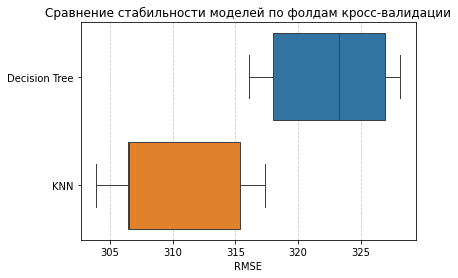

In [54]:
best_rmse_dt = [-x for x in study_dt.best_trial.user_attrs['rmse_all_folds']]
best_rmse_knn = [-x for x in study_knn.best_trial.user_attrs['rmse_all_folds']]

sns.boxplot(data=[best_rmse_dt, best_rmse_knn], orient='h')

plt.yticks(ticks=[0, 1], labels=['Decision Tree', 'KNN'])

plt.title("Сравнение стабильности моделей по фолдам кросс-валидации")
plt.xlabel("RMSE")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


1. Точность k-NN явно лидирует: весь  box plot сдвинут левее по оси RMSE. Медиана k-NN находится в районе 307, в то время как у Decision Tree она сильно хуже — около 324. Даже худший фолд у KNN показал ошибку меньшую, чем средний результат у решающего дерева.
2. Стабильность моделей. Обе модели имеют примерно одинаковый разброс, то есть одинаково чувствительны к конкретному разбиению данных на фолды. 

### Исследование важности признаков

Для исследования важности признаков обе модели с лучшими параметрами нужно обучить на полном наборе данных. 

В решающем дереве важность признаков (Feature Importance) оценивается автоматически в процессе обучения самого дерева. Однако сейчас нас более интересует модель k-NN, которая лидирует по всем трем метрикам. 

В отличие от деревьев решений, у алгоритма k-NN нет встроенного математического свойства вроде важности признаков. Поэтому для оценки важности признаков мы используем метод опеределения важности признаков на основе перестановок - Permutation Importance, который переставляет данные на входе и смотрит на ухудшение метрики на выходе, позволяя нам измерить важность признаков даже для алгоритмов, которые сами этого делать не умеют.

#### Исследование важности признаков k-NN

In [55]:
# 1. Модель с лучшими параметрами от Optuna
best_knn = KNeighborsRegressor(**study_knn.best_params)

# 2. Финальный регрессор (с препроцессингом и логарифмированием целевой переменной)
final_knn_pipeline = Pipeline([
    ('preprocessing', knn_pipeline),
    ('regressor', best_knn)
])

final_knn_model = TransformedTargetRegressor(
    regressor=final_knn_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Обучаем на всех данных 
final_knn_model.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessing',
                                                      Pipeline(steps=[('common_transformer',
                                                                       BikeDataPreprocessor()),
                                                                      ('knn_transformer',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('log_and_scale',
                                                                                                        Pipeline(steps=[('log',
                                                                                                                         FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                                             func...
                                                                                                                         MinMaxScaler())]),
                                                                                                        ['Wind '
                                                                                                         'speed '
                                                                                                         '(m/s)',
                                                                                                         'Solar '
                                                                                                         'Radiation '
                                                                                                         '(MJ/m2)',
                                                                                                         'Rainfall(mm)',
                                                                                                         'Snowfall '
                                                                                                         '(cm)']),
                                                                                                       ('scale',
                                                                                                        MinMaxScaler(),
                                                                                                        ['Humidity(%)',
                                                                                                         'Visibility '
                                                                                                         '(10m)',
                                                                                                         'real_feel']),
                                                                                                       ('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False),
                                                                                                        ['Seasons'])],
                                                                                         verbose_feature_names_out=False))])),
                                                     ('regressor',
                                                      KNeighborsRegressor(n_neighbors=12,
                                                                          p=1,
                                                                          weights='distance'))]))

/tmp/ipykernel_48/155609505.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


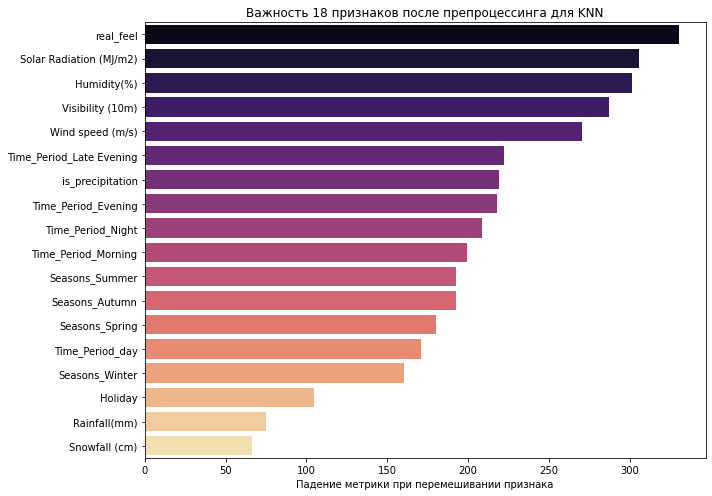

In [56]:
# 1. Трансформируем X_train вручную через препроцессор пайплайна (получаем 18 колонок вместо исходных 15)
preprocessor = final_knn_model.regressor_[:-1]
model_estimator = final_knn_model.regressor_[-1] 

X_train_transformed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out() # Получаем 18 имен

final_estimator = TransformedTargetRegressor(
    regressor=model_estimator,  
    func=np.log1p,              
    inverse_func=np.expm1       
).fit(X_train_transformed, y_train)

# 2. Считаем важность на трансформированных данных (18 признаков)
result = permutation_importance(
    final_estimator, X_train_transformed, y_train, scoring='neg_root_mean_squared_error', n_repeats=10, random_state=42
)

# 3. Сортируем и строим график на 18 признаков
knn_indices = np.argsort(result.importances_mean)[::-1]

plt.figure(figsize=(10, 7))
sns.barplot(
    x=result.importances_mean[knn_indices], 
    y=np.array(feature_names)[knn_indices],  # Сюда пойдут все 18 колонок
    palette="magma"
)
plt.title("Важность 18 признаков после препроцессинга для KNN")
plt.xlabel("Падение метрики при перемешивании признака")
plt.tight_layout()
plt.show()


1. Самый важный признак - созданный нами real_feel - падение метрики (которое мы принимаем за важность признака) более чем на 320 пунктов. Это доказывает, что комплексный расчет ощущаемой температуры — самый сильный фактор для нашей целевой переменной.
2. Далее идут признаки величины солнечной радиации, влажности, видимости, скорости ветра, то есть признаки, детализирующие описание погодных условий.
3. Признаки сезонов и времени суток идут плотной группой с падением метрики от 160 до 220.
4. Количество осадков занимают последние места по падению метрик при перемешивании, в то время как признак факта наличия осадков, созданный нами 'is_precipitation' занимает седьмое место по величине падения метрики  

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Да, отличный признак создали, он логичен и логично, что он хорошо сработал.

#### Исследование важности признаков DT

In [57]:
# 1. Модель с лучшими параметрами от Optuna
best_dt = DecisionTreeRegressor(**study_dt.best_params, random_state=42)

# 2. Финальный регрессор (с препроцессингом и логарифмированием целевой переменной)
final_dt_pipeline = Pipeline([
    ('preprocessing', dt_pipeline),
    ('regressor', best_dt)
])

final_dt_model = TransformedTargetRegressor(
    regressor=final_dt_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# 3. Обучаем на всех данных 
final_dt_model.fit(X_train, y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessing',
                                                      Pipeline(steps=[('common_processing',
                                                                       BikeDataPreprocessor()),
                                                                      ('dt_specific_processing',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('ohe',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False),
                                                                                                        ['Seasons'])],
                                                                                         verbose_feature_names_out=False))])),
                                                     ('regressor',
                                                      DecisionTreeRegressor(max_depth=12,
                                                                            min_samples_leaf=14,
                                                                            min_samples_split=36,
                                                                            random_state=42))]))

/tmp/ipykernel_48/1690850142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


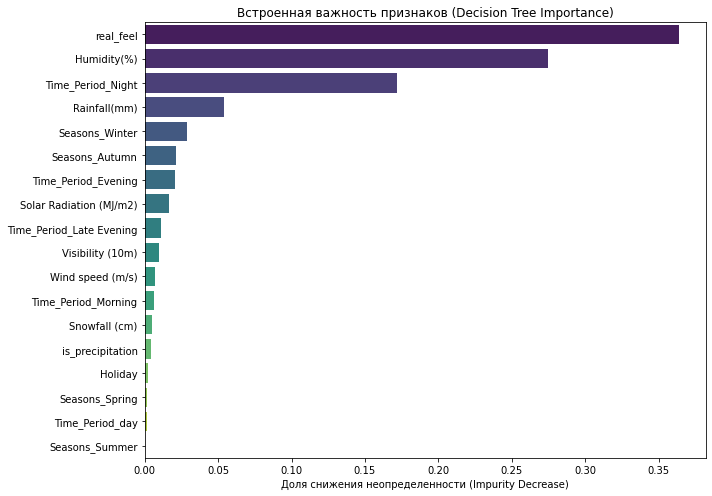

In [58]:
# 1. Получаем имена 18 колонок и саму модель дерева
trained_pipeline = final_dt_model.regressor_
feature_names = trained_pipeline[:-1].get_feature_names_out()
tree_estimator = trained_pipeline[-1]

# 2. Забираем встроенную важность признаков
tree_importances = tree_estimator.feature_importances_

# 3. Сортируем по убыванию
tree_indices = np.argsort(tree_importances)[::-1]

# 4. Строим график
plt.figure(figsize=(10, 7))
sns.barplot(
    x=tree_importances[tree_indices], 
    y=np.array(feature_names)[tree_indices], 
    palette="viridis"
)
plt.title("Встроенная важность признаков (Decision Tree Importance)")
plt.xlabel("Доля снижения неопределенности (Impurity Decrease)")
plt.tight_layout()
plt.show()

1. Как и в модели k-NN по важности лидирует real_feel. На графике видно, что признаки real_feel (ощущаемая температура) и Humidity(%) суммарно забирают более 60% всей важности (около 0.36 и 0.28 соответственно). Дерево решений считает их ключевыми разделителями данных: первые и самые важные «развилки» (сплиты) в структуре дерева строятся именно по этим числовым шкалам.
2. Третьим по важности идет временной признак - Time_Period_Night (около 0,18).
3. Далее признаки, описывающие погоду и временные признаки (сезон и время суток) перемешаны по значения важности, в отличие от k-NN, в которой эти признаки сгруппированы.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍

#### Общий вывод по сравнению важности признаков для моделей



1. Для обеих моделей признают самым важным фактором является ощущаемая температура.
2. Уровень относительной влажности также является важным признаком для обеих моделей: 2 место для дерева решений и 3 место для k-NN.
3. Модель k-NN фактически разделяет по важности признаки на две группы: она сильнее реагирует на признаки, описывающие погоду и, в меньшей степени, на временные признаки: сезоны и время суток.
4. Дерево решений такое разделение на две группы не производит: признаки, описывающие погоду и признаки времени имеют примерно одинаковую важность.  
5. Модель k-NN на обучающей выборке показывает лучший результат, чем дерево решений по всем трем метрикам, по целевой метрике (RMSE) k-NN имеет результат 309.93 против 322,47 у дерева решений. Так что в качестве лучшей модели выбираем k-NN. 

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 

В 3,4 пунктах описываешь факты про наши модели. Кажется, просится какой-то вывод, но его нет. Давай добавим, что решили по фактам наблюдений? Здесь будет уместна аргументация выбора лучшей модели.

<br/> <div class="alert alert-info">
Комментарий студента V1  

Добавил   

## Проверка лучшей модели на тестовой выборке

Лучшей моделью по всем трем метрикам (RMSE, MAE и R2) является модель k-NN со следующими параметрами. 

In [59]:
print("Лучшие параметры для k-NN:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")
print(f"Лучший результат RMSE на кросс-валидации: {study_knn.best_value:.4f}")
print(f"MAE на лучшей попытке: {best_mae_knn:.4f}")
print(f"R² на лучшей попытке: {best_r2_knn:.4f}")

Лучшие параметры для k-NN:
  n_neighbors: 12
  weights: distance
  p: 1
Лучший результат RMSE на кросс-валидации: 309.9261
MAE на лучшей попытке: 211.4618
R² на лучшей попытке: 0.7677


Количество соседей, по которым производится расчет целевой переменной - 12.  
Метрика расстояния имеет степень 1, то есть это манхэттенская метрика.  
Вклад соседа обратно пропорционален расстоянию.

In [60]:
y_pred_knn = full_predict(X_test, final_knn_model)

In [61]:
y_pred_knn.shape, y_test.shape

((1752,), (1752,))

Проверим, как отработала наша функция, обнуляющая предсказание, если день нерабочий.

In [62]:
# 1. Привязываем предсказания к индексам X_test
y_pred_series = pd.Series(y_pred_knn, index=X_test.index)

# 2. Фильтруем предсказания там, где Functioning Day == No
non_functioning_preds = y_pred_series[X_test['Functioning Day'] == 'No']

# 3. Считаем, сколько предсказаний НЕ равны нулю
not_zeros = (non_functioning_preds != 0).sum()

# 4. Выводим результат
print(f"Всего строк, где Functioning Day = No: {len(non_functioning_preds)}")
print(f"Из них НЕ равны нулю: {not_zeros}")

if not_zeros == 0:
    print("Во всех строках с нерабочим днем предсказаны строго нули!")
else:
    print("Внимание: Есть строки, где предсказание не обнулилось!")


Всего строк, где Functioning Day = No: 53
Из них НЕ равны нулю: 0
Во всех строках с нерабочим днем предсказаны строго нули!


In [63]:
rmse_knn = root_mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"RMSE модели k-NN на тестовых данных: {round(rmse_knn,3)}")
print(f"MAE модели k-NN на тестовых данных: {round(mae_knn,3)}")
print(f"R2 модели k-NN на тестовых данных: {round(r2_knn,3)}")


RMSE модели k-NN на тестовых данных: 304.946
MAE модели k-NN на тестовых данных: 198.911
R2 модели k-NN на тестовых данных: 0.773


In [64]:
metrics_final = {
    'model': ['base', 'k-NN train', 'k-NN test'],
    'rmse': [round(rmse_base,3), round(study_knn.best_value,3), round(rmse_knn,3)],
    'mae': [round(mae_base,3), round(best_mae_knn,3), round(mae_knn,3)],
    'r2' : [round(r2_base,3), round(best_r2_knn,3), round(r2_knn,3)]
}

df_metrics_final = pd.DataFrame(metrics_final)
print("=== Финальное сравнение метрик моделей ===")
display(df_metrics_final)

=== Финальное сравнение метрик моделей ===


,model,rmse,mae,r2
0,base,411.564,312.599,0.586
1,k-NN train,309.926,211.462,0.768
2,k-NN test,304.946,198.911,0.773


Модель k-NN на тестовых данных улучшила свои метрики по сравнению с обучающими данными. Причина в том, что в тренировочных данных мы удаляли часть строк, в которых признак 'Functioning Day' = No, а на тестовых данных мы заменили предсказания, полученные для таких дней на 0, чем повысили количество точных предсказаний. 53/1752 = 3 % таких строк. RMSE k-NN test/RMSE k-NN train =304.946/309.926 = 0.984 есть RMSE снизился примерно на 1,16 %
Для корректного сравнения удалим из тестовых данных строки в которых признак 'Functioning Day' = No, сделаем предсказание и подсчитаем метрики.

In [65]:
df_test_red = (df_test[df_test['Functioning Day'] == 'Yes']) 
y_test_red = df_test_red['Rented Bike Count']
X_test_red = df_test_red.drop(columns=['Rented Bike Count'])

In [66]:
X_test_red.shape, y_test_red.shape 

((1699, 15), (1699,))

1752 строки - 53 строки с нерабочими днями = 1699

In [67]:
y_pred_knn_red = final_knn_model.predict(X_test_red)

In [68]:
rmse_knn_red = round(root_mean_squared_error(y_test_red, y_pred_knn_red),3)
mae_knn_red = round(mean_absolute_error(y_test_red, y_pred_knn_red),3)
r2_knn_red = round(r2_score(y_test_red, y_pred_knn_red),3)

In [69]:
df_metrics_final.loc[3] = ['k-NN test redused', rmse_knn_red, mae_knn_red, r2_knn_red] 
print("=== Финальное сравнение метрик моделей ===")
display(df_metrics_final)

=== Финальное сравнение метрик моделей ===


,model,rmse,mae,r2
0,base,411.564,312.599,0.586
1,k-NN train,309.926,211.462,0.768
2,k-NN test,304.946,198.911,0.773
3,k-NN test redused,309.666,205.116,0.764


Анализ изменения метрик при переходе от обучающей выборки (k-NN train) к тестовой (k-NN test redused) показывает качественное и стабильное поведение модели.  

1. Модель не переобучена
- RMSE на тесте практически не изменился (упал с 309.926 до 309.666).
- R² (коэффициент детерминации) остался стабильным, показав микроубывание с 0.768 до 0.764.  
Это значит, что гиперпараметры модели подобраны правильно а также, что тестовая выборка имеет ту же плотность и репрезентативность данных, что и обучающая. 

2. Изменение характера ошибок
В то время как RMSE на тесте не изменился, метрика MAE снизилась (с 211.462 до 205.116, разница -3.%). Это значит, что на тестовой выборке k-NN стал делать чуть меньше мелких ошибок в среднем (уменьшение MAE), но при этом количество крупных ошибок не изменилось (RMSE, который сильнее штрафует за большие отклонения).


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
 
👍 Модель стабильна. Дни простоя из данных и расчетов нужно убрать.
    
Можем общий вывод вынести в самый самый конец проекта, чтобы работа не заканчикалась блоком кода без пояснений.

## Сохранение модели


In [70]:
with open("BikeSochi_knn.pkl", "wb") as f:
    cloudpickle.dump({'model': final_knn_model, 'predict_func': full_predict}, f)

https://github.com/alexsivop-gif/BikeSochi_knn.git

<div class="alert alert-warning">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> 
    
Не могу открыть, пишет page not found. 

<br/> <div class="alert alert-info">
Комментарий студента V1  
Исправлено

In [71]:
with open("BikeSochi_knn.pkl", "rb") as f:
    artifacts = cloudpickle.load(f)

loaded_model = artifacts['model']
loaded_predict_func = artifacts['predict_func']

y_pred_final = loaded_predict_func(X_test, loaded_model)

In [72]:
rmse_knn_final = root_mean_squared_error(y_test, y_pred_final)
mae_knn_final = mean_absolute_error(y_test, y_pred_final)
r2_knn_final = r2_score(y_test, y_pred_final)
print(f"RMSE модели k-NN на тестовых данных: {round(rmse_knn_final,3)}")
print(f"MAE модели k-NN на тестовых данных: {round(mae_knn_final,3)}")
print(f"R2 модели k-NN на тестовых данных: {round(r2_knn_final,3)}")

RMSE модели k-NN на тестовых данных: 304.946
MAE модели k-NN на тестовых данных: 198.911
R2 модели k-NN на тестовых данных: 0.773


## Выводы о результатах работы

Перед нами стояла задача улучшения системы прогнозирования почасового спроса на велосипеды. Базовая модель - модель линейной регрессии по своим качествам не удовлетворяла заказчика.

Тип модели: k-NN или дерево решений.  
Метрики: RMSE, R² и MAE.  
Целевая метрика для выбора модели - RMSE.  

Были созданы:
Функция, обнуляющая предсказания модели для нерабочих дней.
Модель, прогнозирующая почасовой спрос на велосипеды.

В ходе работы были опробованы:
Дерево решений и модель k-NN
Для оценки качества моделей при обучении применялась кросс-валидация с основной метрикой RMSE и вспомогательными метриками MAE и R2.

В ходе оценки моделей были получены следующие метрики качества:

In [73]:
display(df_metrics)

,model,rmse,mae,r2
0,base,411.564089,312.599334,0.586072
1,k-NN,309.926099,211.461814,0.767656
2,DT,322.474095,216.462340,0.748561


Обе модели, и k-NN и дерево решений показали гораздо лучшие метрики, чем базовая модель - линейная регрессия. По значениям всех трех метрик была выбрана лучшая модель - k-NN. 

На тестовой выборке модель k-NN показала следующие результаты:

In [76]:
display(df_metrics_final.iloc[[0, 2]])

,model,rmse,mae,r2
0,base,411.564,312.599,0.586
2,k-NN test,304.946,198.911,0.773


Анализ разницы метрик предсказаний, сделанных на тестовых данных между базовой линейной регрессией и моделью k-NN показывает:
1. RMSE сократился с 411,564 до 304,946, то есть на 25,8 % .
2. MAE сократился с 312,599 до 198,911 - на 36,4 % (больше чем на треть).  
3. Коэффициент детерминации вырос с 0,586 до 0,773, на 31,7 %. 
Модель k-NN демонстрирует гораздо более высокое качество предсказаний.


<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект!  
    
**Отмечу положительные моменты проекта🚀**
    
* Отличная структура
* Достаточно внимательная подготовка признаков, хорошие решения по созданию новых признаков.
* Отличная реализация пайплайнов и кода с Optuna.
    
**На что стоит обратить внимание🤔**
    
* Рекомендую построить гистограммы, уточниться по необходимости логарифмирования, пересмотреть текстовые комментарии.
* Уточнимся по тому, какие признаки лишние.
* Рекомендую прямо прописать аргументацию выбора лучшей модели в промежуточном выводе.
* Эти и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>